# Attention

Everything `probjax.nn` builds on top of attention — `Transformer`, `SimFormer`, the
diffusion denoisers — bottoms out in one of two functions with the *same signature*:

- `dot_product_attention` — materializes the `[Q, K]` score matrix. Runs anywhere.
- `flex_attention` — a fused Pallas/Triton kernel that never materializes it. Needs a GPU.

This notebook explains what they compute, how masks and biases are expressed as
*objects* rather than dense arrays, and when to reach for which.

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from flax import nnx

from probjax.nn.layers.attention import (
    MultiHeadAttention,
    SSMaxQueryScale,
    dot_product_attention,
    flex_attention,
)

jax.config.update("jax_platform_name", "cpu")
print(jax.devices())

[CpuDevice(id=0)]


## 1. What attention computes

Attention is a *soft lookup*. Each query row scores every key, the scores are turned into
a probability distribution with a softmax, and the output is that distribution's weighted
average of the values:

$$\mathrm{attn}(Q, K, V) = \mathrm{softmax}\!\left(\frac{QK^\top}{\sqrt{d}}\right) V$$

To see it doing something recognisable, give 12 tokens one of 3 "types" and make the
query/key vectors one-hot in the type. A token then scores its own type highly and every
other type near zero, so the output is the **mean of the values of its own type** — a
learned `groupby`.

In [2]:
num_tokens, num_types, head_dim = 12, 3, 3

types = jnp.array([0, 1, 2, 0, 0, 1, 2, 2, 1, 0, 1, 2])
# One-hot query/key vectors, scaled so the softmax is decisive rather than lukewarm.
q = k = 4.0 * jax.nn.one_hot(types, num_types)
values = jax.random.normal(jax.random.key(0), (num_tokens, head_dim))

scores = q @ k.T / jnp.sqrt(head_dim)
weights = jax.nn.softmax(scores, axis=-1)
out = weights @ values

# Ground truth: for each token, the mean value over all tokens of the same type.
same_type = types[:, None] == types[None, :]
group_mean = (same_type @ values) / same_type.sum(-1, keepdims=True)
print("output == per-type mean of values:", bool(jnp.allclose(out, group_mean, atol=1e-3)))

output == per-type mean of values: True


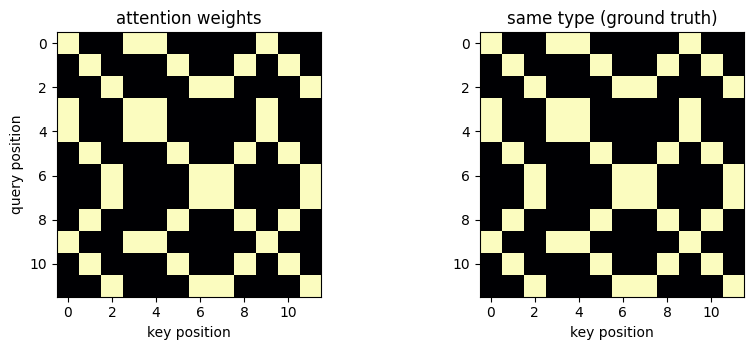

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))
axes[0].imshow(weights, cmap="magma", vmin=0)
axes[0].set(title="attention weights", xlabel="key position", ylabel="query position")
axes[1].imshow(same_type, cmap="magma", vmin=0)
axes[1].set(title="same type (ground truth)", xlabel="key position")
fig.tight_layout()

### Array layout

probjax follows the flax convention: **`(batch, seq, heads, head_dim)`**, with the head
axis *second to last*, not second. This differs from PyTorch's `(batch, heads, seq, dim)`
and is the single most common source of shape errors when porting code.

`dot_product_attention` adds the batch/head axes and the $1/\sqrt{d}$ scale on top of the
computation above, and nothing else — here it is against the hand-rolled version.

In [4]:
batch, seq_len, num_heads, head_dim = 2, 8, 2, 4
keys = jax.random.split(jax.random.key(0), 3)
q = jax.random.normal(keys[0], (batch, seq_len, num_heads, head_dim))
k = jax.random.normal(keys[1], (batch, seq_len, num_heads, head_dim))
v = jax.random.normal(keys[2], (batch, seq_len, num_heads, head_dim))

logits = jnp.einsum("bqhd,bkhd->bhqk", q, k) / jnp.sqrt(head_dim)
manual = jnp.einsum("bhqk,bkhd->bqhd", jax.nn.softmax(logits, axis=-1), v)

print("shape:", dot_product_attention(q, k, v).shape)
print("matches hand-rolled:", bool(jnp.allclose(manual, dot_product_attention(q, k, v), atol=1e-5)))

shape: (2, 8, 2, 4)
matches hand-rolled: True


## 2. `MultiHeadAttention`

The module wraps the function with the four projections — Q, K, V and the output mixing —
and reshapes `(batch, seq, features)` into per-head `(batch, seq, heads, head_dim)` for
you. It is flax's `MultiHeadAttention` plus sharding metadata, pluggable QK normalization
and a query-scaling hook.

In [5]:
features = 32
mha = MultiHeadAttention(
    num_heads=4, in_features=features, qkv_features=features, decode=False, rngs=nnx.Rngs(0)
)
x = jax.random.normal(jax.random.key(1), (batch, seq_len, features))
print("in", x.shape, "-> out", mha(x).shape)

for path, param in nnx.to_flat_state(nnx.state(mha, nnx.Param)):
    print(".".join(str(p) for p in path), tuple(param.shape))

in (2, 8, 32) -> out (2, 8, 32)
key.bias (4, 8)
key.kernel (32, 4, 8)
out.bias (32,)
out.kernel (4, 8, 32)
query.bias (4, 8)
query.kernel (32, 4, 8)
value.bias (4, 8)
value.kernel (32, 4, 8)


### QK normalization and query scaling

Two knobs that matter at depth and at long context:

- **`normalize_qk=True`** normalizes Q and K before the dot product, so logits can't grow
  without bound as the model trains — the standard fix for attention-logit blowup. Swap in
  any norm class via `normalize_q_cls` / `normalize_k_cls` (an `LpNorm` gives you cosine
  similarity attention).
- **`q_scale_cls`** rescales Q *after* normalization and *before* the kernel. Because
  logits are linear in Q, scaling Q is exactly scaling the logits — which is how SSMax
  and QASSMax are defined. These make the softmax temperature depend on the key length,
  countering the attention-entropy drift you get when evaluating at a longer context than
  you trained on.

In [6]:
mha_scaled = MultiHeadAttention(
    num_heads=4,
    in_features=features,
    qkv_features=features,
    decode=False,
    normalize_qk=True,
    q_scale_cls=SSMaxQueryScale,
    rngs=nnx.Rngs(0),
)
print("normalize_qk + SSMax:", mha_scaled(x).shape)

normalize_qk + SSMax: (2, 8, 32)


## 3. Masks are objects, not arrays

Passing a dense `[batch, heads, Q, K]` boolean array costs $O(QK)$ memory and tells the
fused kernel nothing about *structure*. probjax instead describes a mask as an object that
knows how to answer "is `(q_idx, k_idx)` allowed?".

That buys two things: `dot_product_attention` can materialize it on demand with
`.dense(q_len, kv_len)`, while `flex_attention` can use it to **skip whole blocks** it
knows are entirely masked out — the reason a causal kernel costs roughly half a dense one
instead of the same.

The library ships the usual zoo:

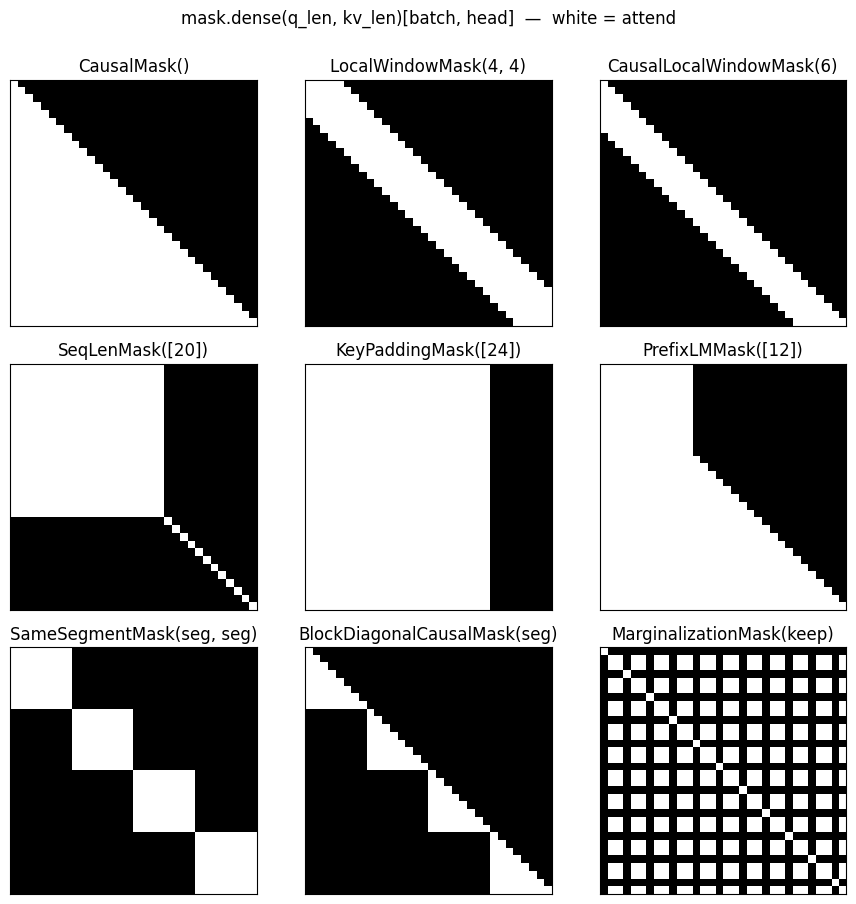

In [7]:
from probjax.nn.pallas_kernels import (
    BlockDiagonalCausalMask,
    CausalLocalWindowMask,
    CausalMask,
    KeyPaddingMask,
    LocalWindowMask,
    MarginalizationMask,
    PrefixLMMask,
    SameSegmentMask,
    SeqLenMask,
)

L = 32
segments = jnp.repeat(jnp.arange(4), L // 4)
gallery = {
    "CausalMask()": CausalMask(),
    "LocalWindowMask(4, 4)": LocalWindowMask(4, 4),
    "CausalLocalWindowMask(6)": CausalLocalWindowMask(6),
    "SeqLenMask([20])": SeqLenMask(jnp.array([20])),
    "KeyPaddingMask([24])": KeyPaddingMask(jnp.array([24])),
    "PrefixLMMask([12])": PrefixLMMask(jnp.array([12])),
    "SameSegmentMask(seg, seg)": SameSegmentMask(segments, segments),
    "BlockDiagonalCausalMask(seg)": BlockDiagonalCausalMask(segments),
    "MarginalizationMask(keep)": MarginalizationMask(jnp.arange(L) % 3 != 0),
}

fig, axes = plt.subplots(3, 3, figsize=(9, 9))
for ax, (name, mask) in zip(axes.flat, gallery.items()):
    ax.imshow(mask.dense(L, L)[0, 0], cmap="Greys_r", vmin=0, vmax=1)
    ax.set(title=name, xticks=[], yticks=[])
fig.suptitle("mask.dense(q_len, kv_len)[batch, head]  —  white = attend", y=1.0)
fig.tight_layout()

`SameSegmentMask` and `BlockDiagonalCausalMask` are the *sequence packing* pattern:
concatenate many short examples into one long row and let the mask keep them from seeing
each other, so no compute is wasted on padding.

`MarginalizationMask` is worth a second look: it drops a *subset of tokens* from the
sequence while keeping the diagonal, so no query row ends up fully masked (which would
make the softmax return `nan`). That is what lets one trained SimFormer evaluate arbitrary
conditionals — see `examples/nn/generative/simformer.ipynb`.

Masks compose with the ordinary Python operators, and composition is what the kernel sees,
so block-skipping still applies:

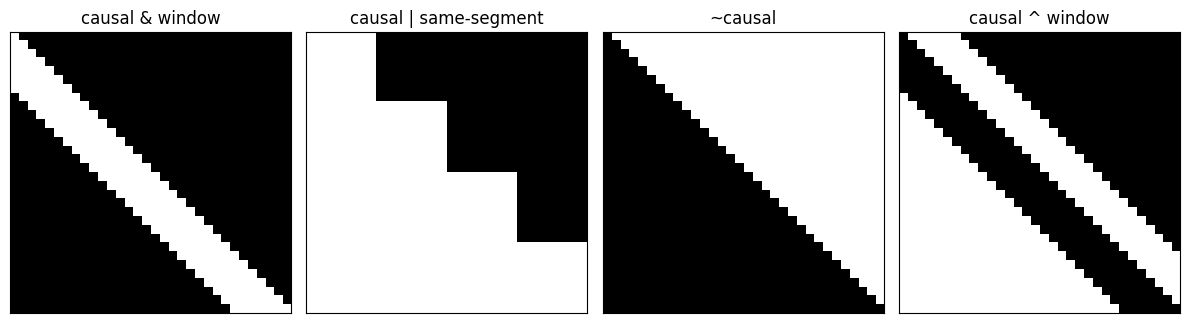

In [8]:
composed = {
    "causal & window": CausalMask() & LocalWindowMask(6, 6),
    "causal | same-segment": CausalMask() | SameSegmentMask(segments, segments),
    "~causal": ~CausalMask(),
    "causal ^ window": CausalMask() ^ LocalWindowMask(6, 6),
}

fig, axes = plt.subplots(1, 4, figsize=(12, 3.2))
for ax, (name, mask) in zip(axes, composed.items()):
    ax.imshow(mask.dense(L, L)[0, 0], cmap="Greys_r", vmin=0, vmax=1)
    ax.set(title=name, xticks=[], yticks=[])
fig.tight_layout()

### Biases

A mask is hard (`-inf` on the logit); a bias is soft (an additive term). Same object
protocol, same `.dense(...)`, passed as `bias=` instead of `mask=`. ALiBi-style biases are
the cheap way to give a model a notion of distance without any position embedding at all —
note the per-head slopes.

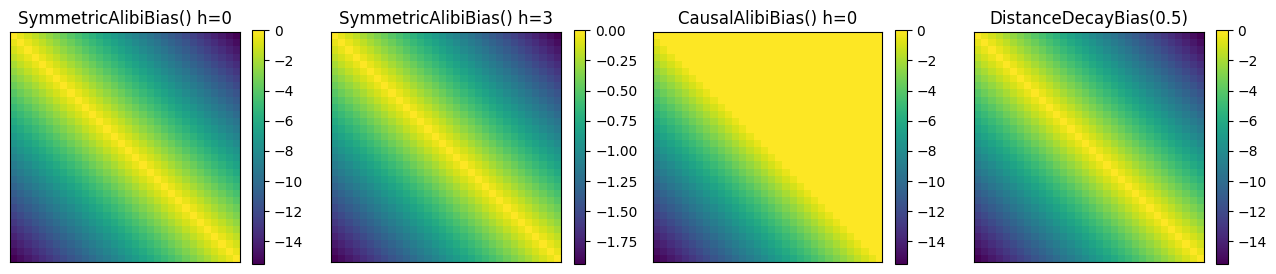

In [9]:
from probjax.nn.pallas_kernels import CausalAlibiBias, DistanceDecayBias, SymmetricAlibiBias

biases = {
    "SymmetricAlibiBias() h=0": (SymmetricAlibiBias(), 0),
    "SymmetricAlibiBias() h=3": (SymmetricAlibiBias(), 3),
    "CausalAlibiBias() h=0": (CausalAlibiBias(), 0),
    "DistanceDecayBias(0.5)": (DistanceDecayBias(0.5), 0),
}

fig, axes = plt.subplots(1, 4, figsize=(13, 3.2))
for ax, (name, (bias, head)) in zip(axes, biases.items()):
    dense = bias.dense(L, L, num_heads=4)[0, head]
    im = ax.imshow(dense, cmap="viridis")
    ax.set(title=name, xticks=[], yticks=[])
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.tight_layout()

## 4. The mask really does constrain the computation

A mask isn't decoration — it changes which inputs the output can depend on. The honest way
to check that is the Jacobian: for a causal model, $\partial\,\mathrm{out}_i/\partial\,x_j$
must be exactly zero for $j > i$. Anything else is a leak, and a leak here is silent —
training looks fine and the model cheats.

This is the check to run whenever you write a custom mask.

causal leak above diagonal: 0.0


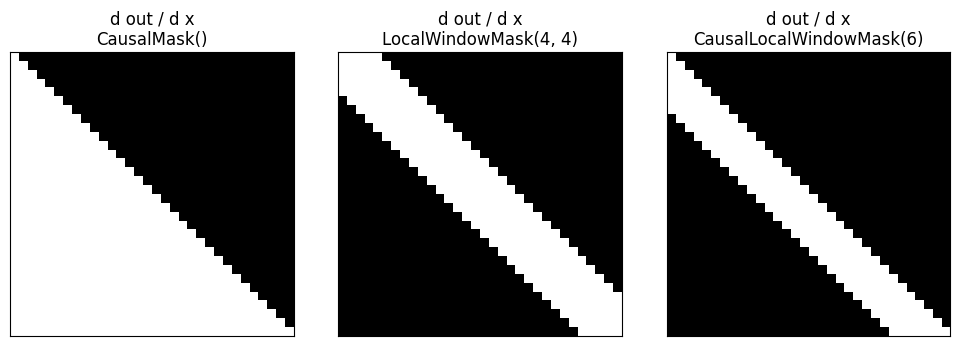

In [10]:
def attend(x, mask):
    # (seq, 1, 1) -> single batch, single head, head_dim 1, so the Jacobian is [S, S].
    x = x.reshape(1, -1, 1, 1)
    return dot_product_attention(x, x, x, mask=mask)[0, :, 0, 0]

probe = jax.random.normal(jax.random.key(0), (L,))
fig, axes = plt.subplots(1, 3, figsize=(10, 3.4))
for ax, (name, mask) in zip(axes, list(gallery.items())[:3]):
    jac = jax.jacobian(attend)(probe, mask)
    ax.imshow(jnp.abs(jac) > 1e-9, cmap="Greys_r", vmin=0, vmax=1)
    ax.set(title=f"d out / d x\n{name}", xticks=[], yticks=[])
fig.tight_layout()

causal_jac = jax.jacobian(attend)(probe, CausalMask())
print("causal leak above diagonal:", float(jnp.abs(jnp.triu(causal_jac, k=1)).max()))

## 5. `flex_attention`: the fused kernel

Same arguments, same masks, different execution: `flex_attention` is a Pallas kernel that
tiles the sequence and streams over blocks, so the `[Q, K]` matrix is never written to
memory. Memory goes from $O(S^2)$ to $O(S)$, which is what makes long context affordable.

**It needs a GPU.** On this CPU machine we run it with `interpret=True`, which emulates the
kernel on small inputs — correct, but slow and pointless for timing. The check that matters
is that it agrees with the reference implementation:

In [11]:
seq = 64
kq, kk_, kv = jax.random.split(jax.random.key(0), 3)
q_l = jax.random.normal(kq, (1, seq, 2, 32))
k_l = jax.random.normal(kk_, (1, seq, 2, 32))
v_l = jax.random.normal(kv, (1, seq, 2, 32))

reference = dot_product_attention(q_l, k_l, v_l, mask=CausalMask())
fused = flex_attention(
    q_l, k_l, v_l, mask=CausalMask(), interpret=True, block_q=32, block_k=32
)
print("max |flex - reference|:", float(jnp.abs(fused - reference).max()))

max |flex - reference|: 3.5762786865234375e-07


On a GPU you drop `interpret=True` and tune the block sizes to the hardware:

```python
out = flex_attention(q, k, v, mask=CausalMask(), block_q=128, block_k=128)
```

To pick block sizes, time the candidates rather than guessing — `probjax.utils.bmutil`
has `benchmark` and `bmit` for exactly this. Numbers are omitted here because they say
more about the machine that rendered the docs than about the kernel.

Either function can be handed to a `Transformer` as `attention_fn=`, so the choice of
backend is one keyword and nothing else in the model changes:

```python
from functools import partial
from probjax.nn import Transformer

model = Transformer(
    model_dim=64, num_heads=4, num_layers=2, attn_size=16,
    attention_fn=partial(flex_attention, mask=CausalMask()),
    rngs=nnx.Rngs(0),
)
```

## 6. Cross-attention and grouped-query attention

Nothing above assumed queries and keys are the same sequence. Two common departures:

- **Cross-attention** — queries from one sequence, keys/values from another, so `Q` and
  `K` lengths differ. This is how conditioning gets into a decoder.
- **Grouped-query attention (GQA)** — fewer key/value heads than query heads, with query
  heads sharing a KV head. Shrinks the decoding KV cache, which is usually the memory
  bottleneck at inference. Pass `enable_gqa=True`; without it the head mismatch is an
  error rather than a silent broadcast.

In [12]:
# Cross-attention: 16 queries attending over 40 keys.
q_c = jax.random.normal(jax.random.key(0), (batch, 16, 4, 8))
k_c = jax.random.normal(jax.random.key(1), (batch, 40, 4, 8))
v_c = jax.random.normal(jax.random.key(2), (batch, 40, 4, 8))
print("cross-attention:", dot_product_attention(q_c, k_c, v_c).shape)

# GQA: 8 query heads sharing 2 key/value heads.
q_g = jax.random.normal(jax.random.key(0), (batch, 16, 8, 8))
k_g = jax.random.normal(jax.random.key(1), (batch, 16, 2, 8))
v_g = jax.random.normal(jax.random.key(2), (batch, 16, 2, 8))
print("grouped-query:  ", dot_product_attention(q_g, k_g, v_g, enable_gqa=True).shape)

cross-attention: (2, 16, 4, 8)


grouped-query:   (2, 16, 8, 8)


## Where to go next

- `transformer.ipynb` — stacking this into `Transformer`, with position encodings,
  cross-attention and context conditioning, and two small trained tasks.
- `sharding.ipynb` — splitting the head axis across devices.
- `examples/nn/generative/` — the models that use all of it.